# Sinusoid Laplace — 5-Seed Evaluation

Same variants as `sinusoidal_laplace.ipynb` but run over 5 random seeds. Checkpoints and figures use the `sinusoid_laplace_5seed` prefix to avoid any overlap with the single-seed outputs.

In [1]:
from pathlib import Path
import sys, os, time, copy
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from scipy.stats import norm as _norm

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "shared").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from shared import (checkpoint_exists, load_checkpoint, save_checkpoint,
                    seed_everything, regression_metrics, load_sinusoid,
                    combine_predictive_std, get_sinusoid_mlp, la_predict,
                    build_laplace_variant)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

SEEDS = [711, 42, 123, 456, 789]
sigma_noise = 0.3
TRAIN_LO, TRAIN_HI = 0.0, 8.0

FIGURES_DIR = os.path.join("..", "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

CHECKPOINT_BASE = str(ROOT / "results" / "checkpoints" / "sinusoid_laplace_5seed")
os.makedirs(CHECKPOINT_BASE, exist_ok=True)

plt.rcParams.update({"font.family": "serif", "font.size": 12,
                     "savefig.dpi": 150, "savefig.bbox": "tight"})
print(f"5-seed Laplace regression | {len(SEEDS)} seeds | checkpoints -> {CHECKPOINT_BASE}")

Device: cuda
5-seed Laplace regression | 5 seeds | checkpoints -> /u/halle/carg/home_at/Documents/BNNs/results/checkpoints/sinusoid_laplace_5seed


In [2]:
# Deterministic evaluation grid (torch.linspace — independent of seed)
x_grid = torch.linspace(-5, 13, 500).numpy()

# Variant specs — identical to single-seed notebook
variant_specs = []
for subset, hessians in [("all", ["diag", "kron", "full"]), ("last_layer", ["full", "kron"])]:
    scope = "all" if subset == "all" else "last layer"
    for hessian in hessians:
        for tune in ["marglik", "gridsearch"]:
            variant_specs.append({
                "variant_name": f"{hessian}_{subset}_{tune}",
                "hessian": hessian, "subset": subset, "tune": tune,
                "plot_title": f"{hessian.capitalize()} / {scope} / {tune}",
            })
for subset in ["all", "last_layer"]:
    scope = "all" if subset == "all" else "last layer"
    variant_specs.append({
        "variant_name": f"kron_{subset}_adam_loop",
        "hessian": "kron", "subset": subset, "tune": "adam_loop",
        "plot_title": f"Kron / {scope} / adam loop",
    })
print(f"Configured {len(variant_specs)} variants x {len(SEEDS)} seeds = "
      f"{len(variant_specs)*len(SEEDS)} total fits")

Configured 12 variants x 5 seeds = 60 total fits


In [3]:
all_seed_metrics = {}   # {seed: {vname: metrics_dict}}
all_seed_preds   = {}   # {seed: {vname: (f_mu_grid, epi_grid, sigma)}}
all_seed_la      = {}   # {seed: {vname: fitted Laplace object}}

for seed in SEEDS:
    print(f"\n{'='*55}\nSEED {seed}  ({SEEDS.index(seed)+1}/{len(SEEDS)})\n{'='*55}")

    # ----- data -----
    d = load_sinusoid(n_data=150, sigma_noise=sigma_noise, batch_size=150, seed=seed, device=device)
    X_train, y_train = d["X_train"], d["y_train"]
    X_val, y_val     = d["X_val"], d["y_val"]
    X_test_id = d["X_test_id"]
    y_test_id = d["y_test_id"]
    y_test_id_np = y_test_id.cpu().flatten().numpy()

    # ----- MAP -----
    criterion = torch.nn.MSELoss()
    X_test_grid = torch.linspace(-5, 13, 500).unsqueeze(-1).to(device)
    map_ckpt = os.path.join(CHECKPOINT_BASE, f"sinusoid_map_seed{seed}.pt")
    map_model = get_sinusoid_mlp(seed, device=device)
    if checkpoint_exists(map_ckpt):
        map_model.load_state_dict(
            load_checkpoint(map_ckpt, map_location=device)["model_state_dict"])
        print("  MAP: loaded checkpoint")
    else:
        opt = torch.optim.Adam(map_model.parameters(), lr=1e-2)
        t0 = time.time()
        for _ in range(1000):
            for xb, yb in d["train_loader"]:
                opt.zero_grad(); loss = criterion(map_model(xb), yb); loss.backward(); opt.step()
        save_checkpoint({"model_state_dict": map_model.state_dict(),
                         "fit_time": time.time()-t0}, map_ckpt)
        print(f"  MAP: trained ({time.time()-t0:.1f}s)")
    map_model.eval()
    with torch.no_grad():
        map_resid_std = float((y_train - map_model(X_train)).std().item())

    seed_metrics, seed_preds = {}, {}
    for spec in variant_specs:
        vname = spec["variant_name"]
        la_ckpt = os.path.join(CHECKPOINT_BASE, f"sinusoid_laplace_{vname}_seed{seed}.pt")

        la = build_laplace_variant(
            get_sinusoid_mlp(seed, device=device), map_model, spec, "regression",
            subset_key="subset", hessian_key="hessian")

        loaded = False
        if checkpoint_exists(la_ckpt):
            payload = load_checkpoint(la_ckpt)
            if isinstance(payload, dict) and payload.get("la_state_dict") is not None:
                la.load_state_dict(payload["la_state_dict"])
                metrics = payload.get("metrics", {})
                loaded = True

        if not loaded:
            t0 = time.time(); la.fit(d["train_loader"])
            metrics = {
                "Hessian_Structure": spec["hessian"],
                "Subset_Of_Weights": spec["subset"],
                "Tune_Method": spec["tune"],
                "Fit_Time (s)": time.time()-t0,
            }
            t1 = time.time()
            if spec["tune"] == "adam_loop":
                log_prior = torch.ones(1, requires_grad=True)
                log_sigma = torch.ones(1, requires_grad=True)
                hyp_opt = torch.optim.Adam([log_prior, log_sigma], lr=1e-1)
                for _ in range(1000):
                    hyp_opt.zero_grad()
                    (-la.log_marginal_likelihood(log_prior.exp(), log_sigma.exp())).backward()
                    hyp_opt.step()
                la.prior_precision = log_prior.exp().detach()
                la.sigma_noise = log_sigma.exp().detach()
            else:
                la.sigma_noise = torch.tensor(map_resid_std)
                if spec["tune"] == "marglik":
                    la.optimize_prior_precision(method="marglik")
                else:
                    la.optimize_prior_precision(method="gridsearch", val_loader=d["val_loader"])
            metrics["Tune_Time (s)"] = time.time()-t1
            metrics["Prior_Precision"] = float(
                np.atleast_1d(la.prior_precision.detach().cpu().numpy())[0])
            metrics["Sigma_Noise"] = float(la.sigma_noise.item())
            save_checkpoint({"la_state_dict": la.state_dict(),
                             "metrics": metrics}, la_ckpt)

        sigma = float(la.sigma_noise.item())
        metrics["Sigma_Noise"] = sigma
        metrics["Prior_Precision"] = float(
            np.atleast_1d(la.prior_precision.detach().cpu().numpy())[0])

        f_mu_grid, epi_grid = la_predict(la, X_test_grid)
        t_inf = time.time()
        mu_id, epi_id = la_predict(la, X_test_id)
        metrics["Inf_Time (s)"] = time.time() - t_inf
        total_id = combine_predictive_std(epi_id, sigma)
        metrics.update(regression_metrics(y_test_id_np, mu_id, total_id))

        seed_metrics[vname] = metrics
        seed_preds[vname] = (f_mu_grid, epi_grid, sigma)
        all_seed_la.setdefault(seed, {})[vname] = la
        print(f"  {vname}: RMSE={metrics.get('RMSE',float('nan')):.4f}  "
              f"NLL={metrics.get('NLL',float('nan')):.4f}  "
              f"Cal={metrics.get('Calibration_MAE',float('nan')):.4f}")

    all_seed_metrics[seed] = seed_metrics
    all_seed_preds[seed] = seed_preds

print(f"\nCompleted {len(SEEDS)} seeds x {len(variant_specs)} variants.")


SEED 711  (1/5)
  MAP: loaded checkpoint


RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!

In [ ]:
# Aggregate metrics across seeds (mean ± std per variant)
metric_keys = [
    "RMSE", "NLL", "Calibration_MAE",
    "Fit_Time (s)", "Tune_Time (s)", "Inf_Time (s)",
]

agg = {}
for spec in variant_specs:
    vname = spec["variant_name"]
    agg[vname] = {}
    for mk in metric_keys:
        vals = [all_seed_metrics[s][vname].get(mk, float("nan")) for s in SEEDS]
        vals = [v for v in vals if not np.isnan(v)]
        agg[vname][f"{mk}_mean"] = float(np.mean(vals)) if vals else float("nan")
        agg[vname][f"{mk}_std"]  = float(np.std(vals))  if len(vals)>1 else 0.0

# Display as mean ± std table
rows = []
for spec in variant_specs:
    vname = spec["variant_name"]
    row = {mk: f"{agg[vname][f'{mk}_mean']:.4f} ± {agg[vname][f'{mk}_std']:.4f}"
           for mk in metric_keys}
    rows.append(row)
summary_df = pd.DataFrame(rows, index=[s["plot_title"] for s in variant_specs])
summary_df.index.name = "Variant"
print(f"Sinusoid Laplace — {len(SEEDS)}-seed metrics (mean ± std)")
display(summary_df)

# Save raw means/stds for downstream use
agg_flat = []
for spec in variant_specs:
    vname = spec["variant_name"]
    row = {"Variant": spec["plot_title"]}
    row.update(agg[vname])
    agg_flat.append(row)
agg_df = pd.DataFrame(agg_flat).set_index("Variant")
os.makedirs("results/metrics", exist_ok=True)
agg_df.to_csv("results/metrics/sinusoid_laplace_5seed_metrics.csv")
print("\nSaved to results/metrics/sinusoid_laplace_5seed_metrics.csv")


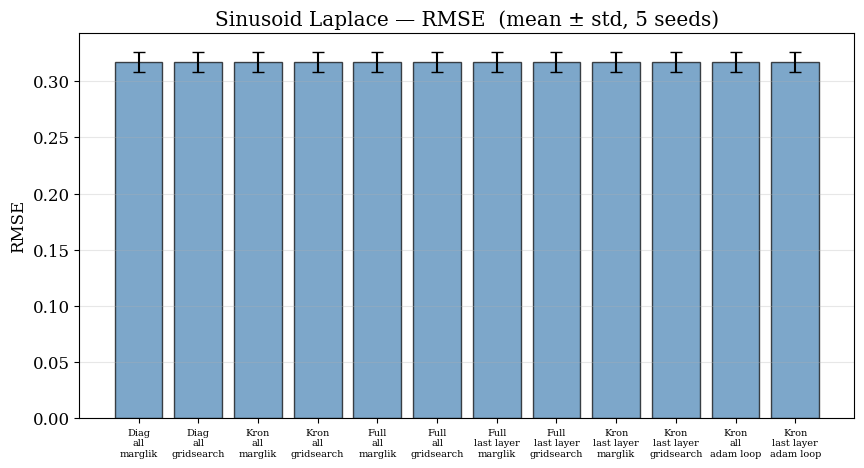

Saved: 5seed_sinusoid_laplace_rmse_bar.png


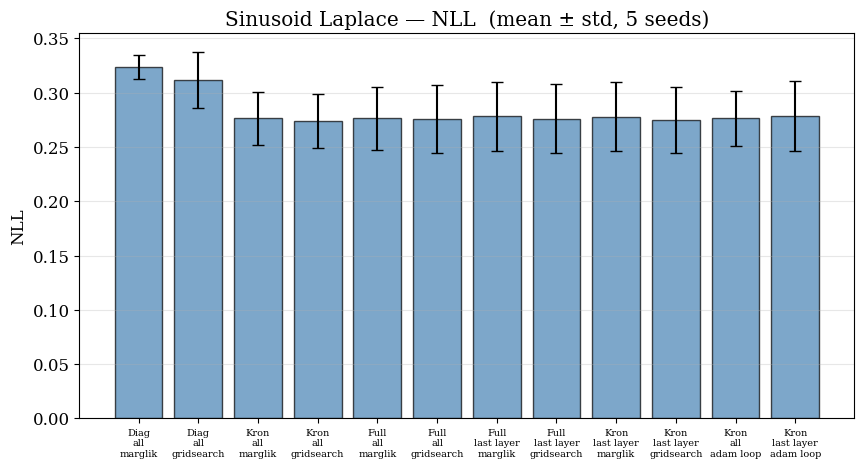

Saved: 5seed_sinusoid_laplace_nll_bar.png


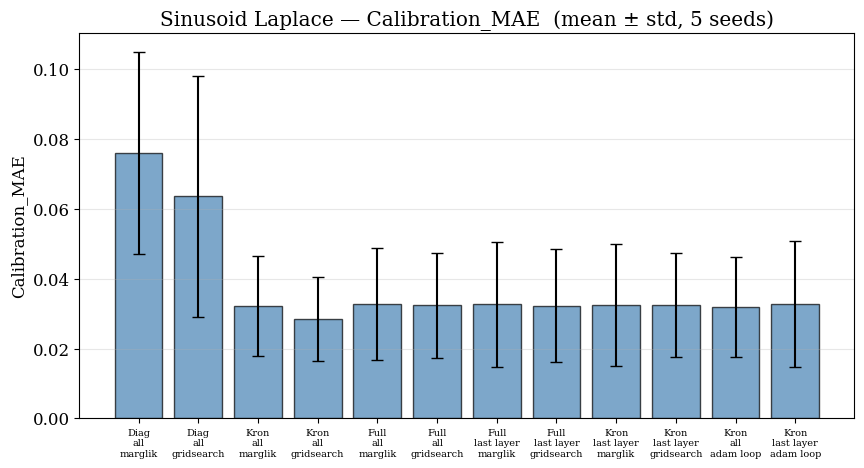

Saved: 5seed_sinusoid_laplace_calibration_mae_bar.png


In [ ]:
plot_metrics = ["RMSE", "NLL", "Calibration_MAE"]
titles = [s["plot_title"] for s in variant_specs]
n = len(titles)
x = np.arange(n)

for mk in plot_metrics:
    means = [agg[s["variant_name"]][f"{mk}_mean"] for s in variant_specs]
    stds  = [agg[s["variant_name"]][f"{mk}_std"]  for s in variant_specs]
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x, means, yerr=stds, capsize=4, color="steelblue", alpha=0.7, edgecolor="k")
    ax.set_xticks(x)
    ax.set_xticklabels([t.replace(" / ", "\n") for t in titles], fontsize=7)
    ax.set_ylabel(mk)
    ax.set_title(f"Sinusoid Laplace — {mk}  (mean ± std, {len(SEEDS)} seeds)")
    ax.grid(True, alpha=0.3, axis="y")
    fname = f"5seed_sinusoid_laplace_{mk.lower()}_bar.png"
    fig.savefig(os.path.join(FIGURES_DIR, fname), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")


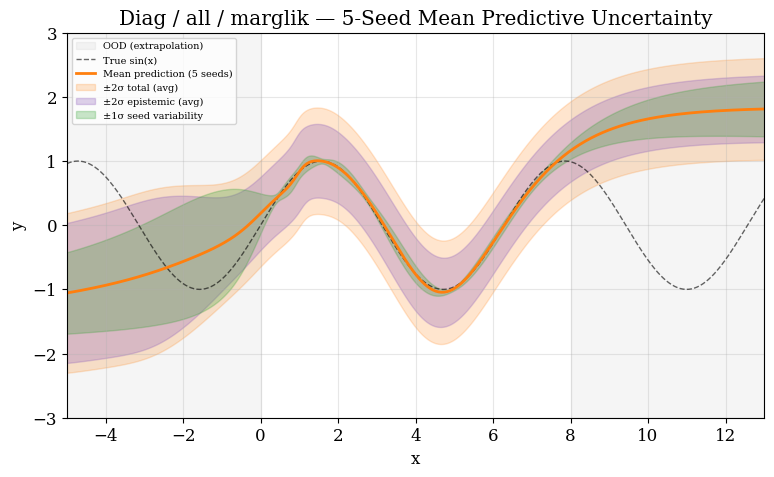

  Saved: 5seed_sinusoid_diag_all_marglik_prediction.png


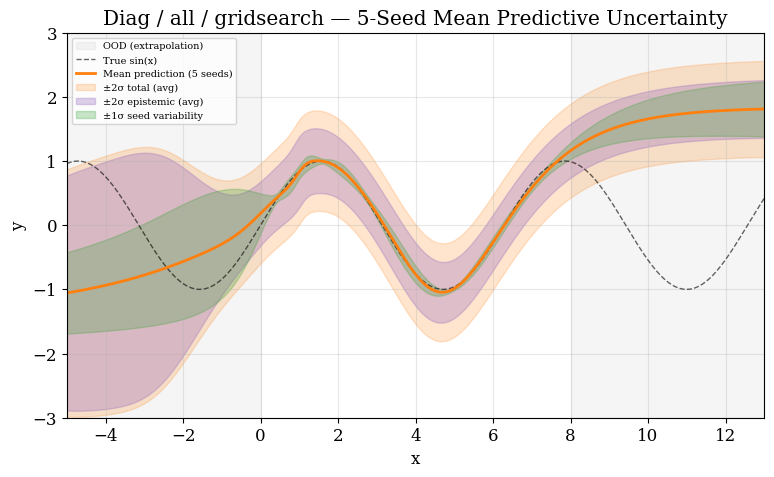

  Saved: 5seed_sinusoid_diag_all_gridsearch_prediction.png


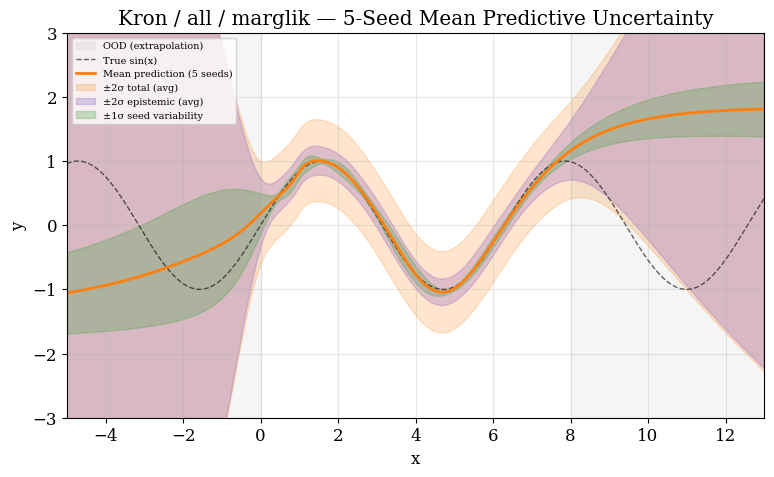

  Saved: 5seed_sinusoid_kron_all_marglik_prediction.png


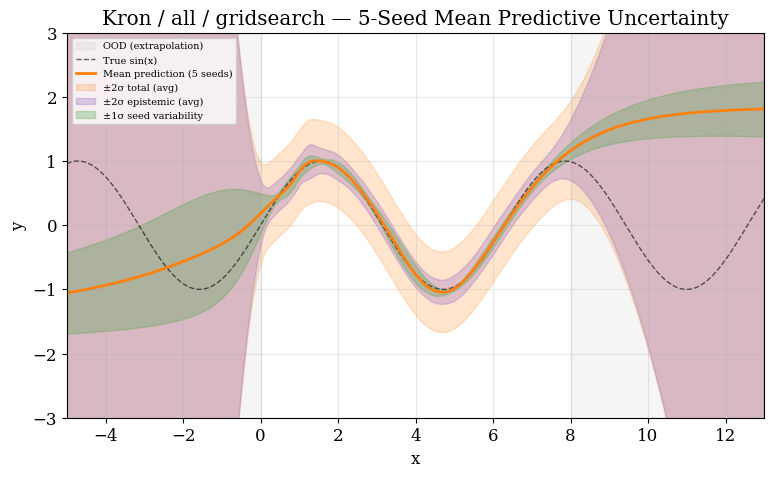

  Saved: 5seed_sinusoid_kron_all_gridsearch_prediction.png


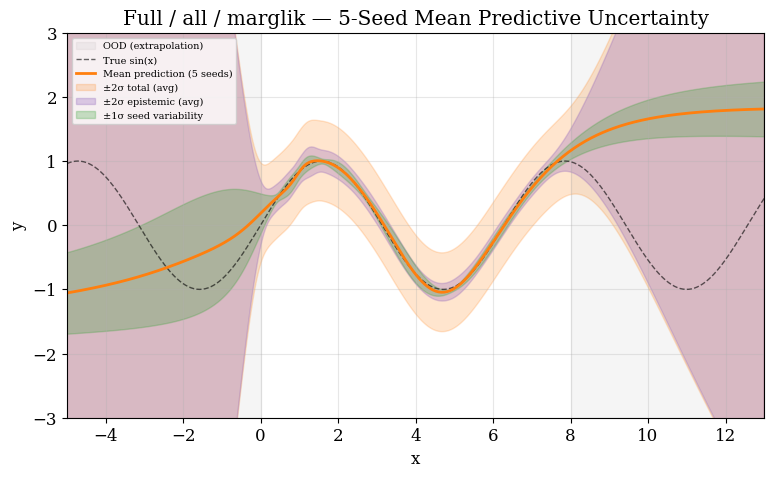

  Saved: 5seed_sinusoid_full_all_marglik_prediction.png


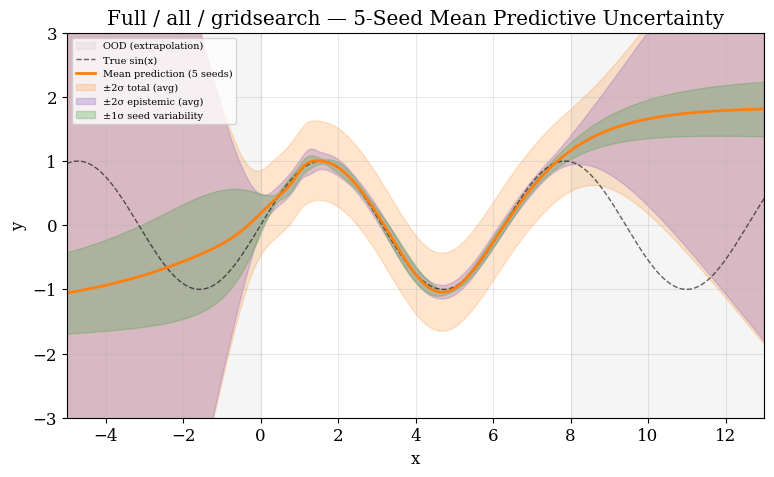

  Saved: 5seed_sinusoid_full_all_gridsearch_prediction.png


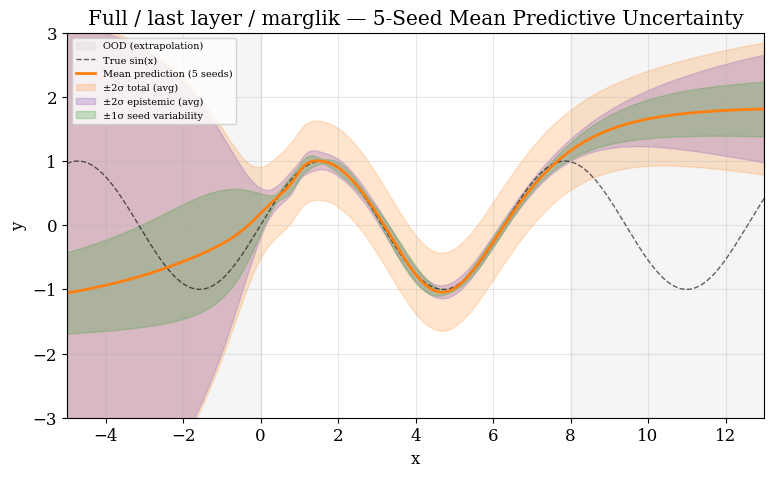

  Saved: 5seed_sinusoid_full_last_layer_marglik_prediction.png


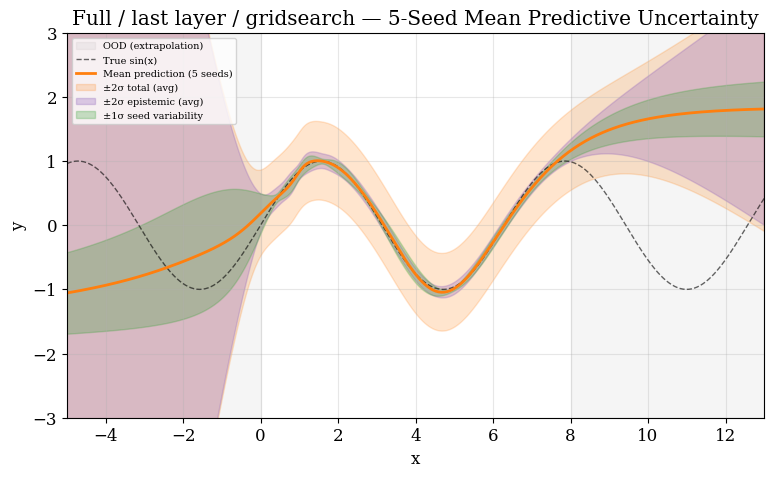

  Saved: 5seed_sinusoid_full_last_layer_gridsearch_prediction.png


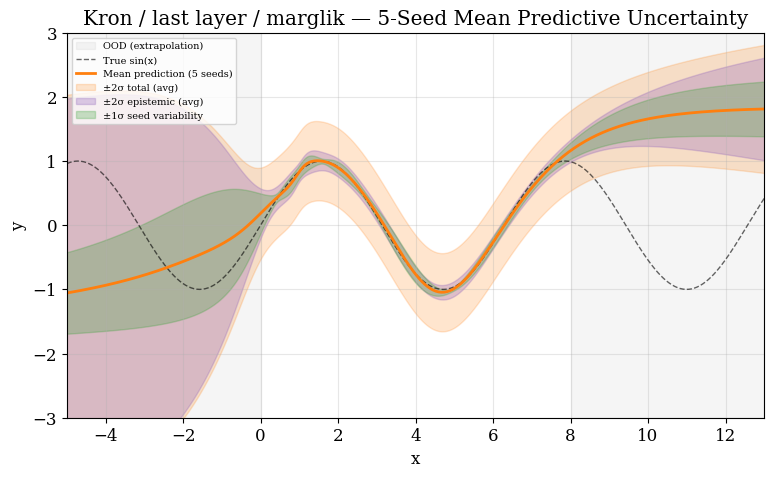

  Saved: 5seed_sinusoid_kron_last_layer_marglik_prediction.png


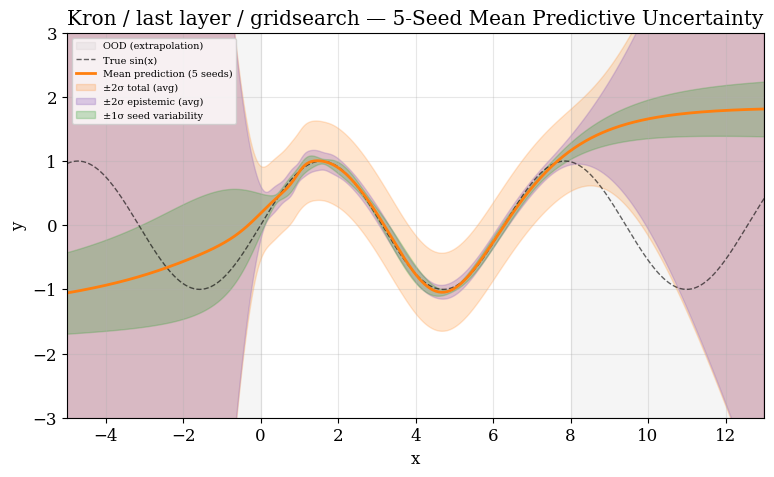

  Saved: 5seed_sinusoid_kron_last_layer_gridsearch_prediction.png


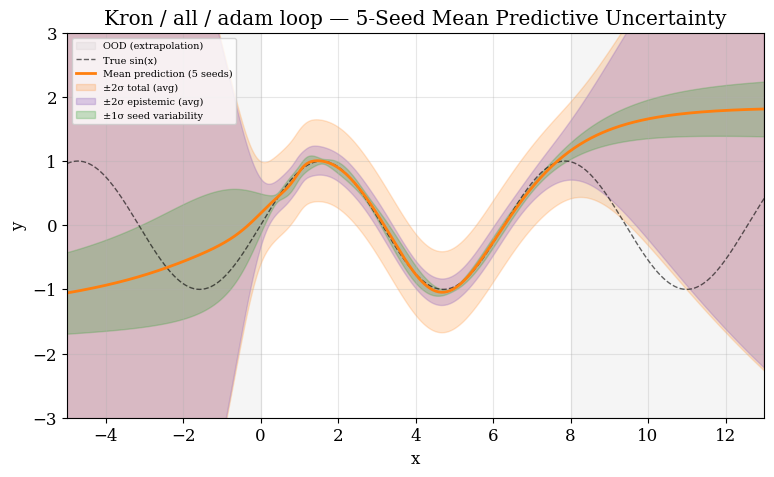

  Saved: 5seed_sinusoid_kron_all_adam_loop_prediction.png


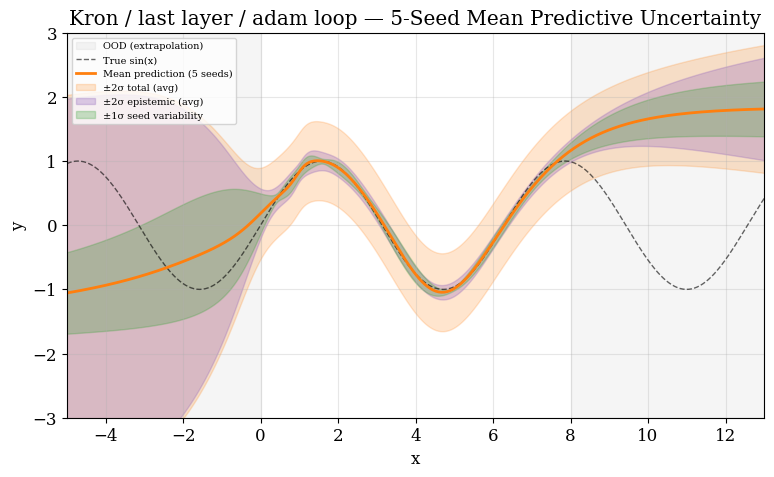

  Saved: 5seed_sinusoid_kron_last_layer_adam_loop_prediction.png

Done: 12 prediction figures


In [ ]:
# Per-variant prediction figures: mean prediction ± uncertainty, averaged across seeds
for spec in variant_specs:
    vname = spec["variant_name"]; title = spec["plot_title"]

    all_mus  = np.stack([all_seed_preds[s][vname][0] for s in SEEDS])  # (S, N)
    all_epis = np.stack([all_seed_preds[s][vname][1] for s in SEEDS])  # (S, N)
    all_sigs = [all_seed_preds[s][vname][2] for s in SEEDS]

    mean_mu  = all_mus.mean(axis=0)
    std_mu   = all_mus.std(axis=0)
    mean_epi = all_epis.mean(axis=0)
    mean_sig = float(np.mean(all_sigs))
    mean_total = combine_predictive_std(mean_epi, mean_sig)

    fig, ax = plt.subplots(1, 1, figsize=(9, 5))
    ax.axvspan(-5, TRAIN_LO, color="gray", alpha=0.08)
    ax.axvspan(TRAIN_HI, 13, color="gray", alpha=0.08, label="OOD (extrapolation)")
    ax.plot(x_grid, np.sin(x_grid), "k--", lw=1, alpha=0.6, label="True sin(x)")
    ax.plot(x_grid, mean_mu, color="tab:orange", lw=2, label="Mean prediction (5 seeds)")
    ax.fill_between(x_grid, mean_mu-2*mean_total, mean_mu+2*mean_total,
                    color="tab:orange", alpha=0.20, label="±2σ total (avg)")
    ax.fill_between(x_grid, mean_mu-2*mean_epi, mean_mu+2*mean_epi,
                    color="tab:purple", alpha=0.30, label="±2σ epistemic (avg)")
    ax.fill_between(x_grid, mean_mu-std_mu, mean_mu+std_mu,
                    color="tab:green", alpha=0.25, label="±1σ seed variability")
    ax.set_xlim(-5, 13); ax.set_ylim(-3, 3)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.set_title(f"{title} — 5-Seed Mean Predictive Uncertainty")
    ax.legend(loc="upper left", fontsize=7); ax.grid(True, alpha=0.3)
    fig.savefig(os.path.join(FIGURES_DIR, f"5seed_sinusoid_{vname}_prediction.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: 5seed_sinusoid_{vname}_prediction.png")
print(f"\nDone: {len(variant_specs)} prediction figures")


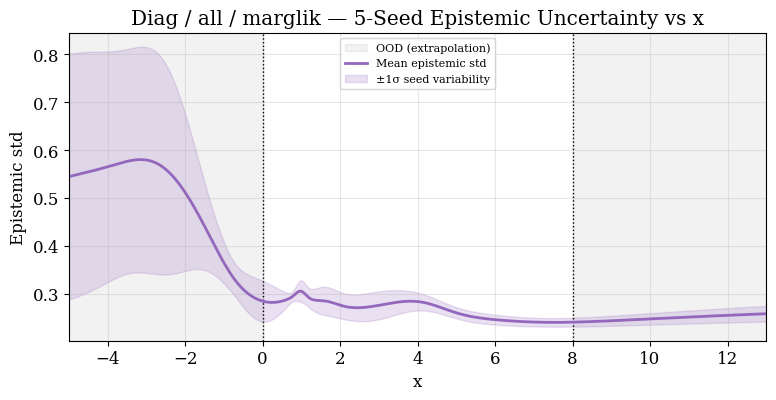

  Saved: 5seed_sinusoid_diag_all_marglik_ood_epistemic.png


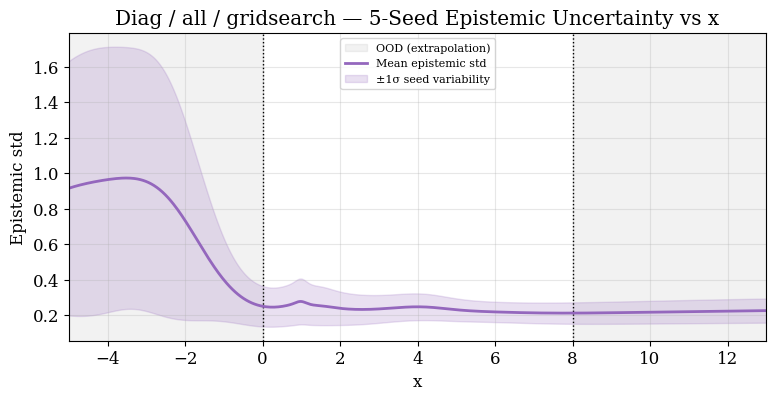

  Saved: 5seed_sinusoid_diag_all_gridsearch_ood_epistemic.png


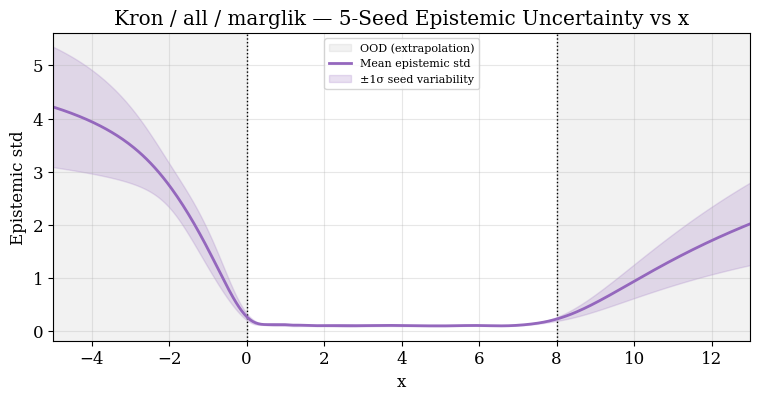

  Saved: 5seed_sinusoid_kron_all_marglik_ood_epistemic.png


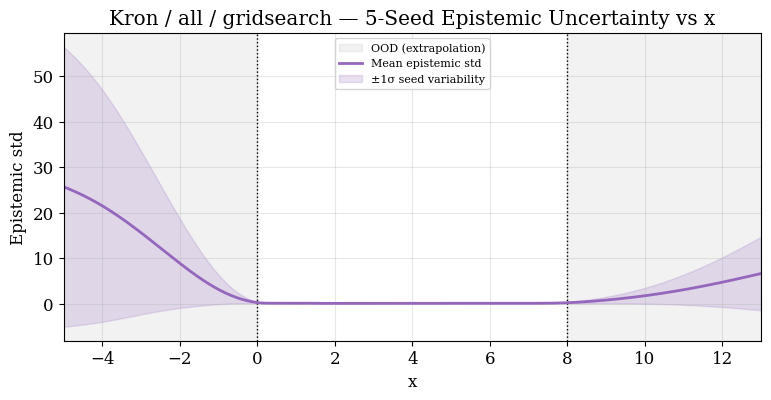

  Saved: 5seed_sinusoid_kron_all_gridsearch_ood_epistemic.png


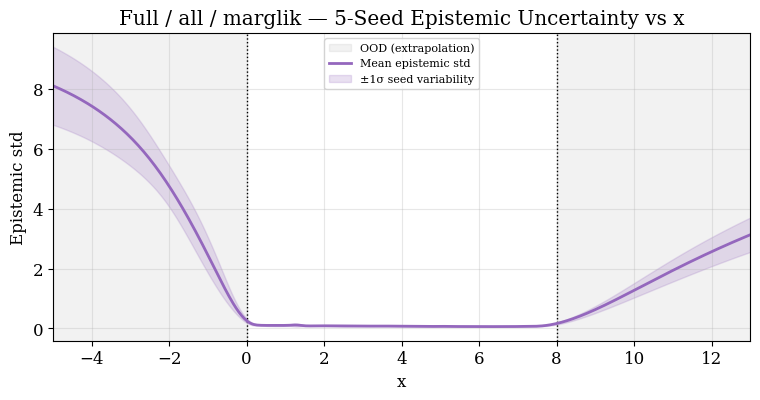

  Saved: 5seed_sinusoid_full_all_marglik_ood_epistemic.png


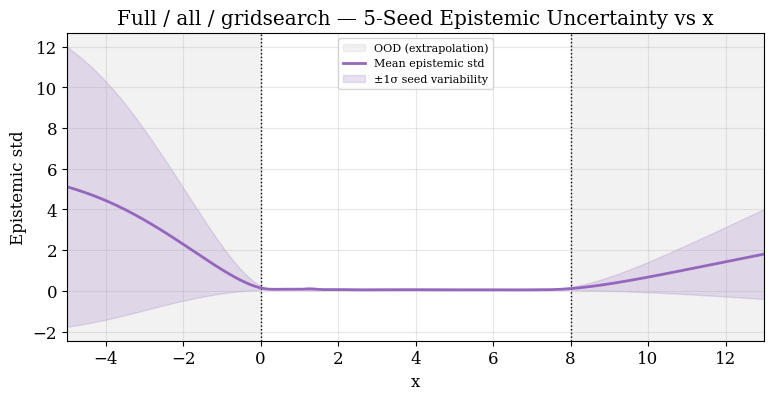

  Saved: 5seed_sinusoid_full_all_gridsearch_ood_epistemic.png


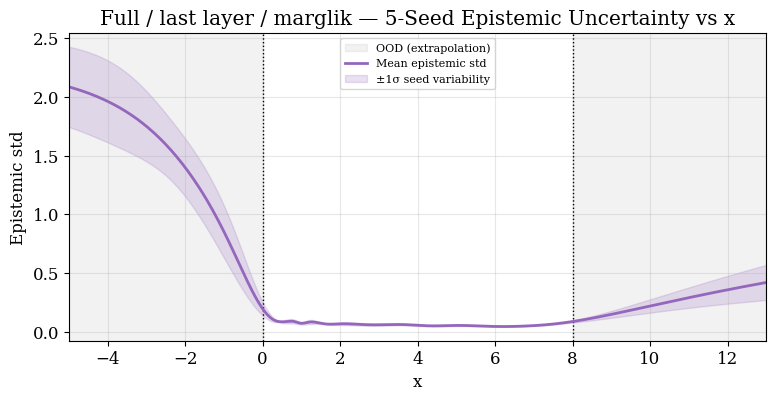

  Saved: 5seed_sinusoid_full_last_layer_marglik_ood_epistemic.png


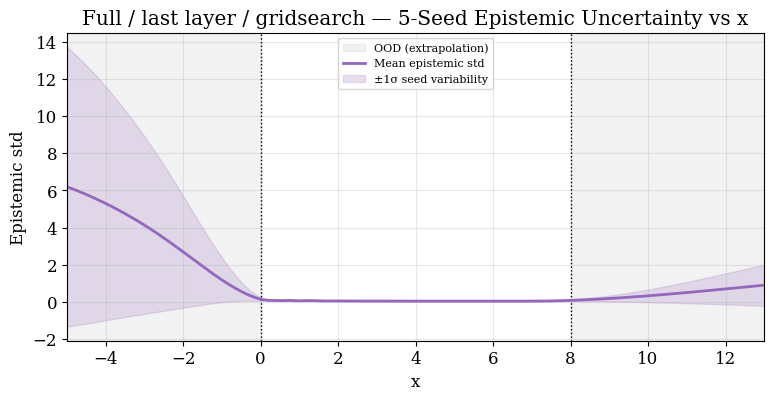

  Saved: 5seed_sinusoid_full_last_layer_gridsearch_ood_epistemic.png


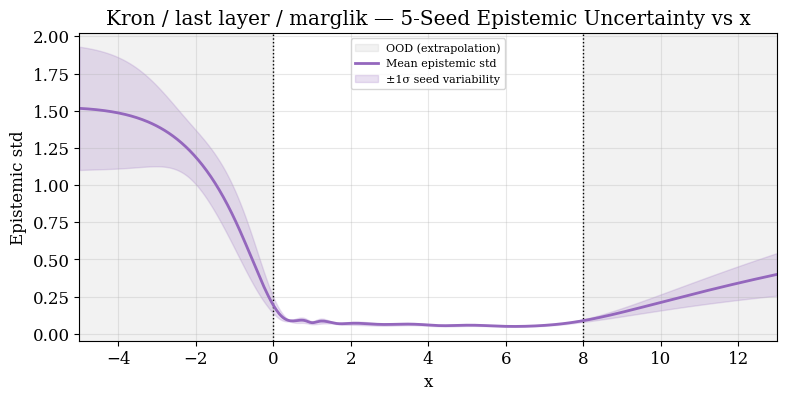

  Saved: 5seed_sinusoid_kron_last_layer_marglik_ood_epistemic.png


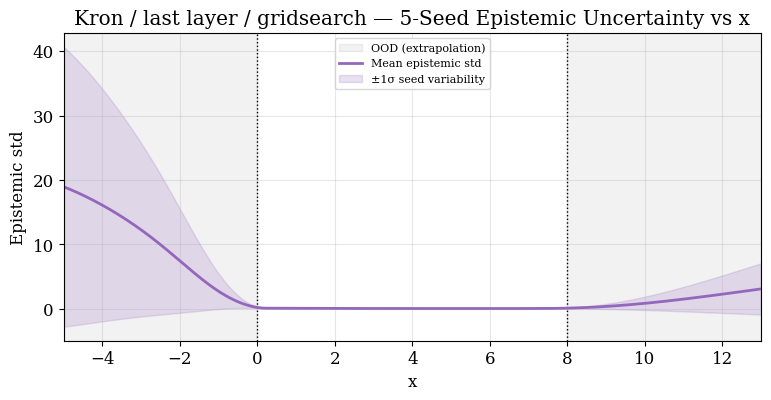

  Saved: 5seed_sinusoid_kron_last_layer_gridsearch_ood_epistemic.png


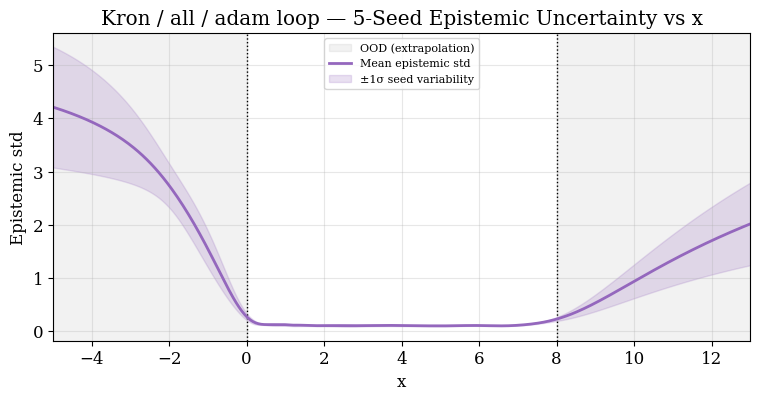

  Saved: 5seed_sinusoid_kron_all_adam_loop_ood_epistemic.png


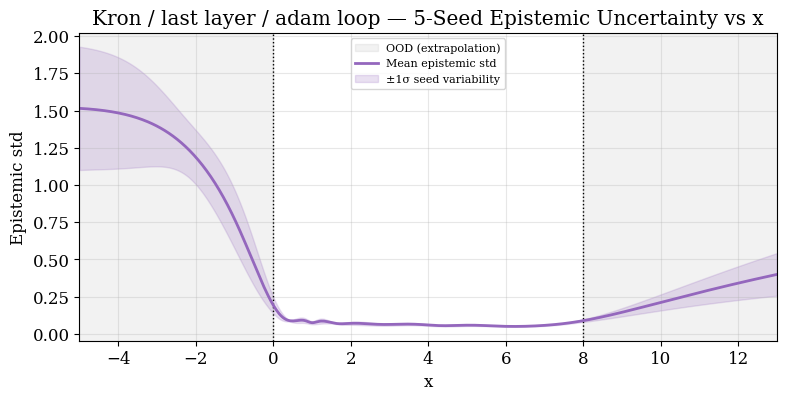

  Saved: 5seed_sinusoid_kron_last_layer_adam_loop_ood_epistemic.png

Done: 12 OOD epistemic figures


In [ ]:
# Per-variant OOD epistemic figures: mean epistemic std ± seed variability
for spec in variant_specs:
    vname = spec["variant_name"]; title = spec["plot_title"]

    all_epis = np.stack([all_seed_preds[s][vname][1] for s in SEEDS])  # (S, N)
    mean_epi = all_epis.mean(axis=0)
    std_epi  = all_epis.std(axis=0)

    fig, ax = plt.subplots(1, 1, figsize=(9, 4))
    ax.axvspan(-5, TRAIN_LO, color="gray", alpha=0.10, label="OOD (extrapolation)")
    ax.axvspan(TRAIN_HI, 13, color="gray", alpha=0.10)
    ax.axvline(TRAIN_LO, color="k", ls=":", lw=1)
    ax.axvline(TRAIN_HI, color="k", ls=":", lw=1)
    ax.plot(x_grid, mean_epi, color="tab:purple", lw=2, label="Mean epistemic std")
    ax.fill_between(x_grid, mean_epi-std_epi, mean_epi+std_epi,
                    color="tab:purple", alpha=0.20, label="±1σ seed variability")
    ax.set_xlim(-5, 13)
    ax.set_xlabel("x"); ax.set_ylabel("Epistemic std")
    ax.set_title(f"{title} — 5-Seed Epistemic Uncertainty vs x")
    ax.legend(loc="upper center", fontsize=8); ax.grid(True, alpha=0.3)
    fig.savefig(os.path.join(FIGURES_DIR, f"5seed_sinusoid_{vname}_ood_epistemic.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: 5seed_sinusoid_{vname}_ood_epistemic.png")
print(f"\nDone: {len(variant_specs)} OOD epistemic figures")


In [ ]:
# Per-variant calibration curves: mean ± std across seeds
conf_levels = np.linspace(0.05, 0.95, 20)
seed_calibration = {seed: {} for seed in SEEDS}

for seed in SEEDS:
    _d = load_sinusoid(n_data=150, sigma_noise=sigma_noise, batch_size=150, seed=seed,
                       device=torch.device("cpu"))
    X_test_id_s = _d["X_test_id"].to(device)
    y_test_id_s = _d["y_test_id"].flatten().numpy()

    for spec in variant_specs:
        vname = spec["variant_name"]
        la = all_seed_la.get(seed, {}).get(vname)
        if la is None:
            print(f"  Warning: {vname} seed {seed} not in memory"); continue
        sigma = float(la.sigma_noise.item())
        mu_id, epi_id = la_predict(la, X_test_id_s)
        total_id = combine_predictive_std(epi_id, sigma)
        resid = y_test_id_s - mu_id
        z_abs = np.abs(resid / np.clip(total_id, 1e-12, None))
        observed = np.array([float(np.mean(z_abs <= _norm.ppf((1+c)/2))) for c in conf_levels])
        seed_calibration[seed][vname] = observed
    print(f"  Seed {seed}: calibration done for {len(seed_calibration[seed])} variants")

for spec in variant_specs:
    vname = spec["variant_name"]; title = spec["plot_title"]
    avail = [seed_calibration[s][vname] for s in SEEDS if vname in seed_calibration[s]]
    if not avail:
        print(f"  Skipping {vname} (no data)"); continue
    obs_matrix = np.stack(avail)
    mean_obs = obs_matrix.mean(axis=0)
    std_obs  = obs_matrix.std(axis=0)
    cal_mae  = float(np.mean(np.abs(mean_obs - conf_levels)))

    fig, ax = plt.subplots(1, 1, figsize=(7, 6))
    ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
    ax.plot(conf_levels, mean_obs, "o-", label=f"Model mean (Cal_MAE={cal_mae:.3f})")
    ax.fill_between(conf_levels, mean_obs - std_obs, mean_obs + std_obs,
                    alpha=0.2, label=f"±1σ across {len(SEEDS)} seeds")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel("Expected confidence"); ax.set_ylabel("Observed coverage")
    ax.set_title(f"{title} — 5-Seed Calibration Reliability Diagram")
    ax.legend(); ax.grid(True, alpha=0.3)
    fig.savefig(os.path.join(FIGURES_DIR, f"5seed_sinusoid_{vname}_calibration.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: 5seed_sinusoid_{vname}_calibration.png")
print(f"\nDone: {len(variant_specs)} calibration figures")